- [Original-jupyter](https://docs.databricks.com/aws/en/notebooks/source/mlflow/mlflow-model-registry-example.html)
<br>
- [Manual](https://learn.microsoft.com/zh-tw/azure/machine-learning/how-to-log-view-metrics?view=azureml-api-2&tabs=interactive)


-----------------
<h3>Data Fetch</h3>

In [1]:
import pandas as pd
wind_farm_data = pd.read_csv("https://github.com/dbczumar/model-registry-demo-notebook/raw/master/dataset/windfarm_data.csv", index_col=0)

def get_training_data():
  training_data = pd.DataFrame(wind_farm_data["2014-01-01":"2018-01-01"])
  X = training_data.drop(columns="power")
  y = training_data["power"]
  return X, y

def get_validation_data():
  validation_data = pd.DataFrame(wind_farm_data["2018-01-01":"2019-01-01"])
  X = validation_data.drop(columns="power")
  y = validation_data["power"]
  return X, y

def get_weather_and_forecast():
  format_date = lambda pd_date : pd_date.date().strftime("%Y-%m-%d")
  today = pd.Timestamp('today').normalize()
  week_ago = today - pd.Timedelta(days=5)
  week_later = today + pd.Timedelta(days=5)
  
  past_power_output = pd.DataFrame(wind_farm_data)[format_date(week_ago):format_date(today)]
  weather_and_forecast = pd.DataFrame(wind_farm_data)[format_date(week_ago):format_date(week_later)]
  if len(weather_and_forecast) < 10:
    past_power_output = pd.DataFrame(wind_farm_data).iloc[-10:-5]
    weather_and_forecast = pd.DataFrame(wind_farm_data).iloc[-10:]

  return weather_and_forecast.drop(columns="power"), past_power_output["power"]

In [2]:
wind_farm_data["2019-01-01":"2019-01-14"].head(10)
# The data is a time series of wind farm power output and weather data.

,temperature_00,wind_direction_00,wind_speed_00,temperature_08,wind_direction_08,wind_speed_08,temperature_16,wind_direction_16,wind_speed_16,power
2019-01-01,8.875944,97.246960,11.665322,11.955358,98.636955,12.240791,14.668171,112.411930,9.737414,8509.6200
2019-01-02,15.183593,150.793730,10.765375,11.806581,202.014570,5.050459,8.744499,299.835420,6.469718,3876.5240
2019-01-03,5.572408,278.278230,2.968834,8.377396,98.699100,7.120559,9.474814,200.089770,1.316572,1511.1980
2019-01-04,7.883471,83.243490,1.943103,10.387258,147.142290,2.183379,10.536873,318.377930,2.621120,256.9488
2019-01-05,8.764894,305.704250,5.041509,8.271966,291.500180,4.422956,7.382129,113.804474,4.078743,1014.6314
2019-01-06,5.438333,106.043320,5.787299,7.966585,139.703280,2.067099,6.946286,285.241820,2.774709,859.2375
2019-01-07,4.202758,207.217350,2.983574,6.853256,112.100510,7.334027,8.428836,112.508860,9.337582,3766.5713
2019-01-08,7.556848,106.699104,9.850532,9.393202,100.567024,10.189929,10.031277,99.752014,8.621423,6999.7627
2019-01-09,7.387094,98.269590,8.638614,9.839335,98.169464,8.310448,10.385242,102.197290,3.762180,3924.3154
2019-01-10,7.586321,213.040680,1.303631,9.785772,91.479225,3.234444,9.988096,110.400520,7.184761,1593.0924


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


Model Structure
-----------------


In [4]:
#Model Structure
# The model is a simple feedforward neural network with one hidden layer.
def train_keras_model(X, y):
  
  model = Sequential()
  model.add(Dense(100, input_shape=(X_train.shape[-1],), activation="relu", name="hidden_layer"))
  model.add(Dense(1))
  model.compile(loss="mse", optimizer="adam")

  model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=.2)
  return model

訓練模型
-----------------
<hr>

In [5]:
import mlflow
import mlflow
import mlflow.keras
import mlflow.tensorflow
import mlflow.tensorflow

X_train, y_train = get_training_data()
with mlflow.start_run() as run:         ##mlflow:start_run()
    mlflow.tensorflow.autolog()         #mlflow:autolog() 
    train_keras_model(X_train, y_train)
    run_id = mlflow.active_run().info.run_id    ##mlflow:run_id
    print(f"Model saved in run {run_id}")

c:\Users\ygz08\Desktop\Git\localgit\MLOPs\MLflow\mlflow-env\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025/04/30 20:22:28 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.


Epoch 1/100
 1/19 ━━━━━━━━━━━━━━━━━━━━ 8s 451ms/step - loss: 9598598.0000

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 10127258.0000 - val_loss: 7664916.0000
Epoch 2/100
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5831400.0000

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9016471.0000 - val_loss: 7145168.5000
Epoch 3/100
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 11353566.0000

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9555307.0000 - val_loss: 6622812.5000
Epoch 4/100
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9040244.0000

...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1377733.7500 - val_loss: 1085907.0000
Epoch 99/100
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1213455.0000

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1313073.7500 - val_loss: 1048813.3750
Epoch 100/100
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1640787.2500

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1237713.6250 - val_loss: 1013598.8125


2025/04/30 20:22:42 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/04/30 20:22:42 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/04/30 20:22:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model saved in run fc90c0ef3ea449eb8dfeccbc6c21ad24


註冊模型
-----------------
<hr>

In [ ]:
mlflow.set_experiment("power-forecasting")  #設置實驗號 ##必要

model_name = "power-forecasting-model"
model_uri = f"runs:/{run_id}/model"
model_details = mlflow.register_model(model_uri, model_name)  #註冊+命名模型丟到models下 #version=1 

2025/04/30 20:22:48 INFO mlflow.tracking.fluent: Experiment with name 'power-forecasting' does not exist. Creating a new experiment.
Registered model 'power-forecasting-model' already exists. Creating a new version of this model...
Created version '3' of model 'power-forecasting-model'.


-----------------
<h3>新增模型描述

In [7]:
from mlflow.tracking.client import MlflowClient
client = MlflowClient()

client.update_registered_model(
  name=model_details.name,
  description="This model forecasts the power output of a wind farm based on weather data. " \
  "The weather data consists of three features: wind speed, wind direction, and air temperature."
)

<RegisteredModel: aliases={}, creation_timestamp=1746015335161, description=('This model forecasts the power output of a wind farm based on weather data. '
 'The weather data consists of three features: wind speed, wind direction, and '
 'air temperature.'), last_updated_timestamp=1746015768852, latest_versions=[<ModelVersion: aliases=[], creation_timestamp=1746015335207, current_stage='Production', description=('This model version was built using TensorFlow Keras. It is a feed-forward '
 'neural network with one hidden layer.'), last_updated_timestamp=1746015335272, name='power-forecasting-model', run_id='be2da52ad8054ab0a3d156268d469b59', run_link=None, source='file:///C:/Users/ygz08/Desktop/Git/localgit/MLOPs/MLflow/mlruns/0/be2da52ad8054ab0a3d156268d469b59/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=1>,
 <ModelVersion: aliases=[], creation_timestamp=1746015379089, current_stage='Staging', description=('This model version is a random forest 

-----------------
<h3>新增模型版本描述

In [8]:
from mlflow.tracking.client import MlflowClient
client = MlflowClient()

client.update_model_version(
  name=model_details.name,
  version=model_details.version,
  description="This model version was built using TensorFlow Keras. It is a feed-forward neural network with one hidden layer."
)

<ModelVersion: aliases=[], creation_timestamp=1746015768820, current_stage='None', description=('This model version was built using TensorFlow Keras. It is a feed-forward '
 'neural network with one hidden layer.'), last_updated_timestamp=1746015768872, name='power-forecasting-model', run_id='fc90c0ef3ea449eb8dfeccbc6c21ad24', run_link=None, source='file:///C:/Users/ygz08/Desktop/Git/localgit/MLOPs/MLflow/mlruns/0/fc90c0ef3ea449eb8dfeccbc6c21ad24/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=3>

執行模型階段轉換
---------------
<hr>
<h3>設定模型階段

In [9]:
from mlflow.tracking.client import MlflowClient
client = MlflowClient()

client.transition_model_version_stage(
  name=model_details.name,
  version=model_details.version,
  stage='Production',
)

C:\Users\ygz08\AppData\Local\Temp\ipykernel_14176\864646331.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1746015768820, current_stage='Production', description=('This model version was built using TensorFlow Keras. It is a feed-forward '
 'neural network with one hidden layer.'), last_updated_timestamp=1746015768891, name='power-forecasting-model', run_id='fc90c0ef3ea449eb8dfeccbc6c21ad24', run_link=None, source='file:///C:/Users/ygz08/Desktop/Git/localgit/MLOPs/MLflow/mlruns/0/fc90c0ef3ea449eb8dfeccbc6c21ad24/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=3>

<h3>查看模型階段

In [10]:
from mlflow.tracking.client import MlflowClient
client = MlflowClient()

model_version_details = client.get_model_version(
  name=model_details.name,
  version=model_details.version,
)
print("The current model stage is: '{stage}'".format(stage=model_version_details.current_stage))

The current model stage is: 'Production'


<h3>拿取最後版本模型的階段

In [11]:
latest_version_info = client.get_latest_versions(model_name, stages=["Production"])
latest_production_version = latest_version_info[0].version
print("The latest production version of the model '%s' is '%s'." % (model_name, latest_production_version))

The latest production version of the model 'power-forecasting-model' is '3'.


C:\Users\ygz08\AppData\Local\Temp\ipykernel_14176\2760805992.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version_info = client.get_latest_versions(model_name, stages=["Production"])


Load Model
---------------------

In [12]:
#mlflow.sklearn.load_model()    #用於載入以 MLflow 格式儲存的 scikit-learn 模型
#mlflow.tensorflow.load_model() #用於載入以 MLflow 格式儲存的 Tensorflow Keras 模型
import mlflow.pyfunc
model_name = 'power-forecasting-model'
model_version = 1 #最新版本號
model_uri = f"models:/{model_name}/{model_version}" #models:/power-forecasting-model/3
model_version_1 = mlflow.pyfunc.load_model(model_uri) #載入模型
print(f'Loading registered model version from URI: {model_uri}') #印出模型資訊

Loading registered model version from URI: models:/power-forecasting-model/1


c:\Users\ygz08\Desktop\Git\localgit\MLOPs\MLflow\mlflow-env\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Visualizations
--------------

Original Version
---

In [13]:
def plot(model_name, model_stage, model_version, power_predictions, past_power_output):
    import pandas as pd
    import matplotlib.dates as mdates
    from matplotlib import pyplot as plt
    index = power_predictions.index
    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111)
    ax.set_xlabel("Date", size=20, labelpad=20)
    ax.set_ylabel("Power\noutput\n(MW)", size=20, labelpad=60, rotation=0)
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.plot(index[:len(past_power_output)], past_power_output, label="True", color="red", alpha=0.5, linewidth=4)
    ax.plot(index, power_predictions.squeeze(), "--", label="Predicted by '%s'\nin stage '%s' (Version %d)" % (model_name, model_stage, model_version), color="blue", linewidth=3)
    ax.set_ylim(ymin=0, ymax=max(3500, int(max(power_predictions.values) * 1.3)))
    ax.legend(fontsize=14)
    plt.title("Wind farm power output and projections", size=24, pad=20)
    plt.tight_layout()
    display(plt.show())
    
def forecast_power(model_name, model_stage):
    from mlflow.tracking.client import MlflowClient
    client = MlflowClient()
    model_version = client.get_latest_versions(model_name, stages=[model_stage])[0].version
    model_uri = "models:/{model_name}/{model_stage}".format(model_name=model_name, model_stage=model_stage)
    model = mlflow.pyfunc.load_model(model_uri)
    weather_data, past_power_output = get_weather_and_forecast()
    power_predictions = pd.DataFrame(model.predict(weather_data))
    power_predictions.index = pd.to_datetime(weather_data.index)
    print(power_predictions)
    plot(model_name, model_stage, int(model_version), power_predictions, past_power_output)

C:\Users\ygz08\AppData\Local\Temp\ipykernel_14176\3294331117.py:23: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  model_version = client.get_latest_versions(model_name, stages=[model_stage])[0].version
c:\Users\ygz08\Desktop\Git\localgit\MLOPs\MLflow\mlflow-env\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
                      0
2020-12-22  1872.308838
2020-12-23  2309.634033
2020-12-24  3391.669189
2020-12-25  4401.589844
2020-12-26  4149.768066
2020-12-27  2627.756348
2020-12-28  3718.418457
2020-12-29  5132.855469
2020-12-30  3048.576172
2020-12-31  2131.641846


C:\Users\ygz08\AppData\Local\Temp\ipykernel_14176\3294331117.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_ylim(ymin=0, ymax=max(3500, int(max(power_predictions.values) * 1.3)))


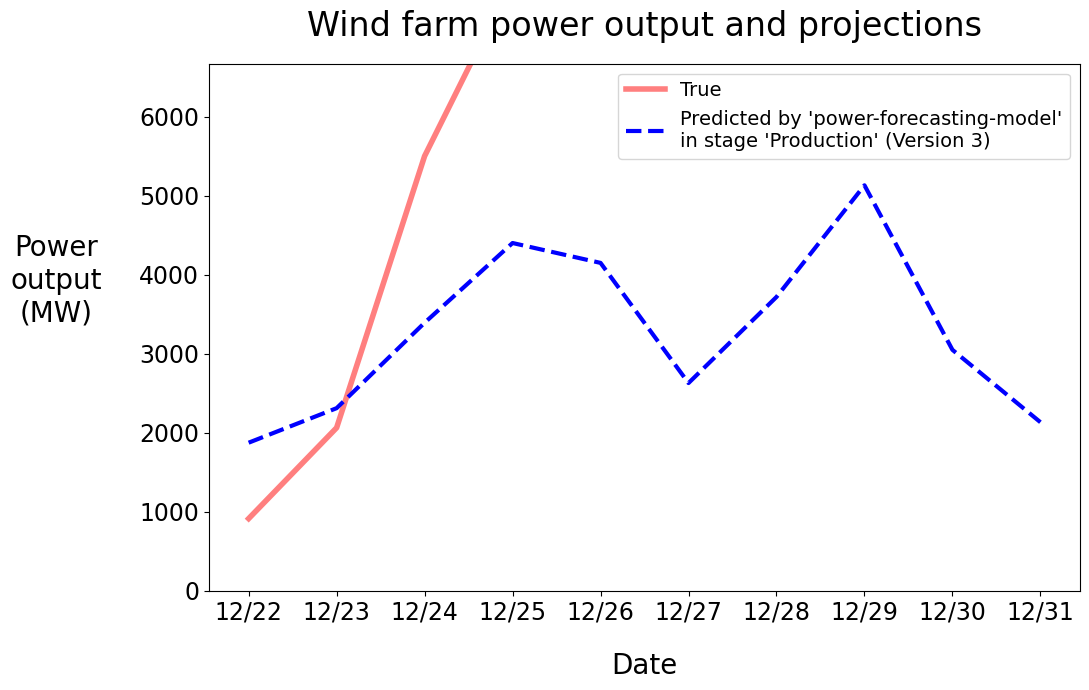

None

In [14]:
forecast_power(model_name, "Production")

Edited
------

In [15]:
def plot_Easy(model_name, power_predictions, past_power_output):
  import pandas as pd
  import matplotlib.dates as mdates
  from matplotlib import pyplot as plt
  index = power_predictions.index
  fig = plt.figure(figsize=(11, 7))
  ax = fig.add_subplot(111)
  ax.set_xlabel("Date", size=20, labelpad=20)
  ax.set_ylabel("Power\noutput\n(MW)", size=20, labelpad=60, rotation=0)
  ax.tick_params(axis='both', which='major', labelsize=17)
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
  ax.plot(index[:len(past_power_output)], past_power_output, label="True", color="red", alpha=0.5, linewidth=4)
  ax.plot(index, power_predictions.squeeze(), "--", label="Predicted by '%s'" % (model_name), color="blue", linewidth=3)
  ax.set_ylim(ymin=0, ymax=max(3500, int(max(power_predictions.values) * 1.3)))
  ax.legend(fontsize=14)
  plt.title("Wind farm power output and projections", size=24, pad=20)
  plt.tight_layout()
  display(plt.show())

def forecast_power_Easy(model):
  from mlflow.tracking.client import MlflowClient
  client = MlflowClient()
  weather_data, past_power_output = get_weather_and_forecast()
  power_predictions = pd.DataFrame(model.predict(weather_data))
  power_predictions.index = pd.to_datetime(weather_data.index)
  print(power_predictions)
  plot_Easy(model_name, power_predictions, past_power_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
                      0
2020-12-22  1917.726685
2020-12-23  2406.650635
2020-12-24  3552.321045
2020-12-25  4617.821777
2020-12-26  4347.922852
2020-12-27  2740.103027
2020-12-28  3886.335938
2020-12-29  5398.245605
2020-12-30  3179.299805
2020-12-31  2197.220215


C:\Users\ygz08\AppData\Local\Temp\ipykernel_14176\1269004317.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_ylim(ymin=0, ymax=max(3500, int(max(power_predictions.values) * 1.3)))


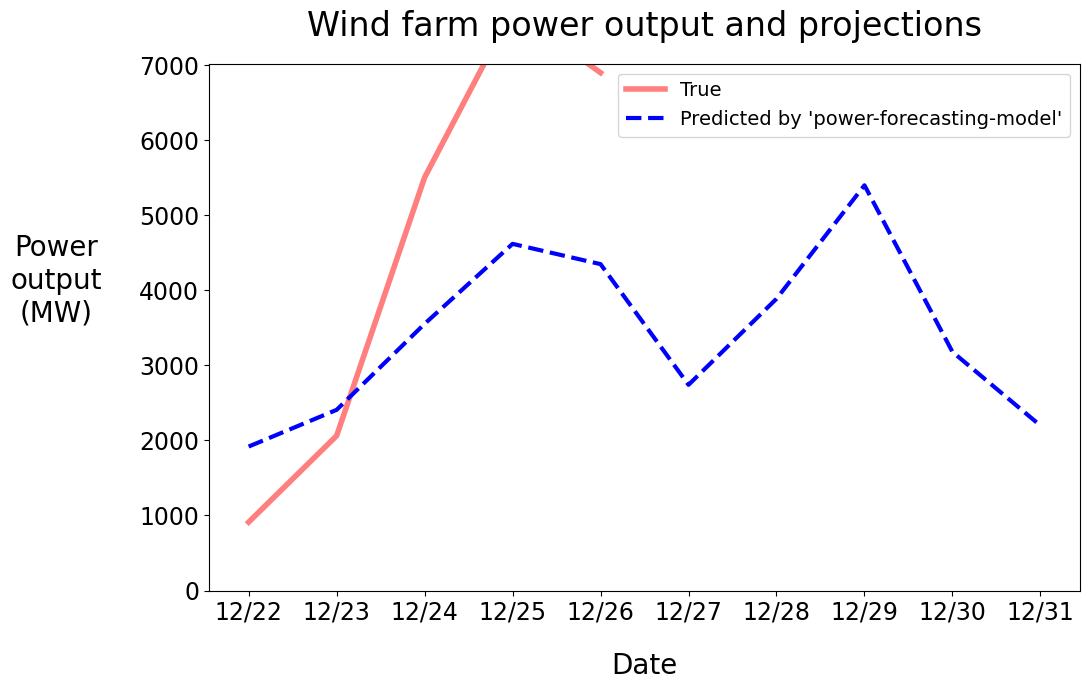

None

In [16]:
forecast_power_Easy(model_version_1)

用SKlearn隨機森林跑並存模型
-----------

In [ ]:
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

with mlflow.start_run():
  n_estimators = 300
  mlflow.log_param("n_estimators", n_estimators) #紀錄參數n_estimators
  
  rand_forest = RandomForestRegressor(n_estimators=n_estimators)
  rand_forest.fit(X_train, y_train)

  val_x, val_y = get_validation_data()
  mse = mean_squared_error(rand_forest.predict(val_x), val_y)
  print("Validation MSE: %d" % mse)
  mlflow.log_metric("mse", mse) #紀錄參數mse
  
  # Specify the `registered_model_name` parameter of the `mlflow.sklearn.log_model()`
  # function to register the model with the MLflow Model Registry. This automatically
  # creates a new model version
  mlflow.sklearn.log_model(     #mlflow.sklearn.log_model() #紀錄sklearn模型
    sk_model=rand_forest, 
    artifact_path="sklearn-model",
    registered_model_name=model_name,  #
  )

Validation MSE: 44753


2025/04/30 20:22:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'power-forecasting-model' already exists. Creating a new version of this model...
Created version '4' of model 'power-forecasting-model'.


<h3>增加新模型版本描述
<hr>

In [18]:
from mlflow.tracking.client import MlflowClient
client = MlflowClient()

model_version_infos = client.search_model_versions("name = '%s'" % model_name) #get all versions of the model
#Get the latest version of the model in models folder
new_model_version = max([model_version_info.version for model_version_info in model_version_infos])


client.update_model_version(
  name=model_name,
  version=new_model_version,
  description="This model version is a random forest containing 100 decision trees that was trained in scikit-learn."
)

<ModelVersion: aliases=[], creation_timestamp=1746015774843, current_stage='None', description=('This model version is a random forest containing 100 decision trees that was '
 'trained in scikit-learn.'), last_updated_timestamp=1746015774881, name='power-forecasting-model', run_id='590d6885a9654fdea82ec31f5ff24972', run_link=None, source='file:///c:/Users/ygz08/Desktop/Git/localgit/MLOPs/MLflow/mlruns/747043707698398460/590d6885a9654fdea82ec31f5ff24972/artifacts/sklearn-model', status='READY', status_message=None, tags={}, user_id=None, version=4>

In [19]:
#模型階段改為Staging
client.transition_model_version_stage(
  name=model_name,
  version=new_model_version,
  stage="Staging",
)

C:\Users\ygz08\AppData\Local\Temp\ipykernel_14176\2979604359.py:2: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1746015774843, current_stage='Staging', description=('This model version is a random forest containing 100 decision trees that was '
 'trained in scikit-learn.'), last_updated_timestamp=1746015774898, name='power-forecasting-model', run_id='590d6885a9654fdea82ec31f5ff24972', run_link=None, source='file:///c:/Users/ygz08/Desktop/Git/localgit/MLOPs/MLflow/mlruns/747043707698398460/590d6885a9654fdea82ec31f5ff24972/artifacts/sklearn-model', status='READY', status_message=None, tags={}, user_id=None, version=4>

C:\Users\ygz08\AppData\Local\Temp\ipykernel_14176\1269004317.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_ylim(ymin=0, ymax=max(3500, int(max(power_predictions.values) * 1.3)))


                      0
2020-12-22  1181.061417
2020-12-23  2320.677955
2020-12-24  5323.893340
2020-12-25  7687.980538
2020-12-26  6893.455769
2020-12-27  2769.012423
2020-12-28  5081.249009
2020-12-29  8731.070375
2020-12-30  3790.609671
2020-12-31  1436.453422


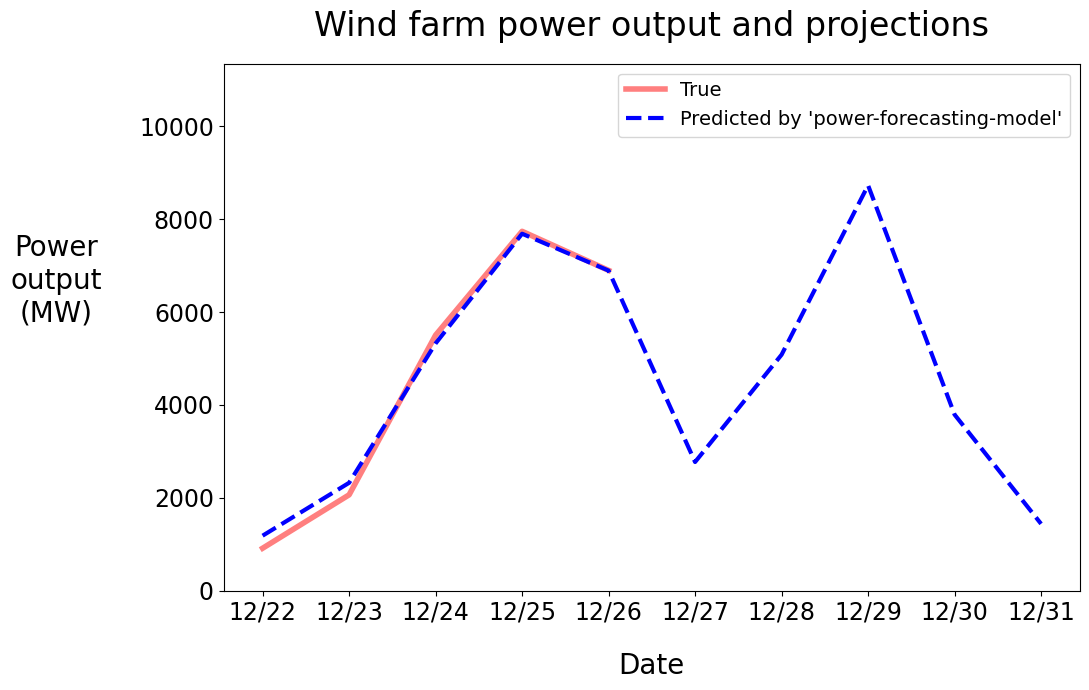

None

In [20]:
forecast_power_Easy(rand_forest) #預測

Delete Models
-----------

In [21]:
'''
client.delete_model_version(
 name=model_name,
 version=1,
)
'''

'\nclient.delete_model_version(\n name=model_name,\n version=1,\n)\n'

In [22]:
####Delete all models#########
#######client.delete_registered_model(name=model_name)